# Applied Machine Learning Experiment: Regularized Logistic Regression

**Author:** Dorsa Norouzi  
**Project Type:** Machine Learning Practice / Portfolio Demo  
**Year:** 2026

## Project Overview

This notebook presents an applied machine learning experiment focused on regularized logistic regression and nonlinear decision boundaries.

The workflow uses a microchip quality-assurance dataset with two test measurements. The goal is to classify whether a microchip should be accepted or rejected based on the test results. Polynomial feature mapping is used to make logistic regression capable of learning nonlinear boundaries, while regularization is used to control overfitting.

## What This Experiment Demonstrates

- Binary classification with logistic regression
- Polynomial feature mapping
- Regularized cost and gradient implementation
- Numerical optimization with SciPy
- Nonlinear decision-boundary visualization
- Effect of different regularization values
- Interpretation of overfitting and underfitting in classification

## Portfolio Note

This notebook is presented as a cleaned portfolio version of an academic machine learning practice experiment. The focus is on demonstrating classification workflow, regularization, decision-boundary analysis, and documentation of model behavior.

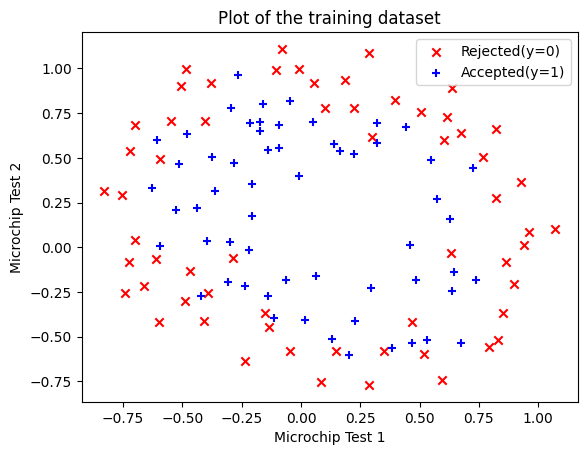

In [ ]:
%matplotlib notebook
%matplotlib inline
import matplotlib.pylab as plt
import numpy as np

filename = "datasets/microchips-dataset.csv"
mydata = np.genfromtxt(filename, delimiter=",") #############################
n = len(mydata) # we have n data-points
X = mydata[:, :2] # input data matrix (with n lines and 2 columns)
y = mydata[:, -1] # vector of n outputs


X0 = X[ y == 0 ]
X1 = X[ y == 1 ]
fig , ax = plt.subplots()

ax.scatter(X0[:,0], X0[:,1], color='red', marker='x', label='Rejected(y=0)')

ax.scatter(X1[:,0], X1[:,1], color='blue', marker='+', label='Accepted(y=1)')

ax.set_xlabel("Microchip Test 1")
ax.set_ylabel("Microchip Test 2")
ax.set_title("Plot of the training dataset")

plt.legend()
plt.show()

## Polynomial Feature Mapping

The dataset is not linearly separable using the original two input features. Polynomial feature mapping expands the feature space, allowing logistic regression to learn nonlinear decision boundaries.

In [ ]:
# Feature mapping function to polynomial features. This function Maps a dataset of two input 
# features X1, X2 (which must be of the same size) to quadratic features. Returns a new feature 
# array with more features, comprising of X1, X2, (X1**2), (X2**2), X1*X2, X1*(X2**2), etc..
def mapFeature(X1, X2):
    degree = 6
    col = 0
    out = np.ones((len(X1), 27))
    for i in range(1, degree+1):
        for j in range(0, i+1):
            out[:, col] = (X1**(i-j)) * (X2**j)
            col += 1
    
    out = np.c_[ np.ones(len(out)), out ] # add a first column of ones
    return out

# We call mapFeature on the original dataset X (with two features) to get a mapped 
# dataset X_poly with 28 features (which already includes a first column of ones).
X_poly = mapFeature(X[:, 0], X[:, 1])
print("Shape of X_poly is:", X_poly.shape)

print("A small subset of X_poly is:\n", X_poly[:5])

Shape of X_poly is: (118, 28)
A small subset of X_poly is:
 [[ 1.00000000e+00  5.12670000e-02  6.99560000e-01  2.62830529e-03
   3.58643425e-02  4.89384194e-01  1.34745327e-04  1.83865725e-03
   2.50892595e-02  3.42353606e-01  6.90798869e-06  9.42624411e-05
   1.28625106e-03  1.75514423e-02  2.39496889e-01  3.54151856e-07
   4.83255257e-06  6.59422333e-05  8.99809795e-04  1.22782870e-02
   1.67542444e-01  1.81563032e-08  2.47750473e-07  3.38066048e-06
   4.61305487e-05  6.29470940e-04  8.58939846e-03  1.17205992e-01]
 [ 1.00000000e+00 -9.27420000e-02  6.84940000e-01  8.60107856e-03
  -6.35227055e-02  4.69142804e-01 -7.97681228e-04  5.89122275e-03
  -4.35092419e-02  3.21334672e-01  7.39785525e-05 -5.46363780e-04
   4.03513411e-03 -2.98012201e-02  2.20094970e-01 -6.86091891e-06
   5.06708697e-05 -3.74226408e-04  2.76382476e-03 -2.04120477e-02
   1.50751849e-01  6.36295342e-07 -4.69931780e-06  3.47065055e-05
  -2.56322636e-04  1.89305413e-03 -1.39810280e-02  1.03255971e-01]
 [ 1.00000000e

## Regularized Logistic Regression Cost and Gradient

This section implements the regularized logistic regression cost function and gradient. Regularization helps control model complexity after polynomial feature expansion.

In [ ]:
# This sigmoid function works on a scalar value as well as a vector or a matrix
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

#Scalar value so we Use sum() to compute the total sum
""" 
Writing the definition of the cost function E(..) for regularized logistic regression. 
"""
def E(theta, X, y, lmd):
    n = len(y)
    h = sigmoid(X @ theta)

    cost = (-1/n) * np.sum(y *np.log(h) +(1-y) * np.log(1-h))
    reg_term = (lmd / (2*n)) * np.sum(theta[1:] ** 2)

    return cost + reg_term

#Vector (gradient for each feature) so we Use X.T @ (h - y) for vectorized summation
""" 
Writing the definition of the corresponding gradient function gradE(..)
"""
def gradE(theta, X, y, lmd):
    n = len(y)
    h = sigmoid(X @ theta)
    grad = (1/n) * (X.T @ (h-y))
    grad[1:] += (lmd / n) * theta[1:]

    return grad


""" 
Call the cost function and gradient using the initial value of theta (initialized to all zeros) and lmd = 0
"""
theta_init = np.zeros(X_poly.shape[1])
lmd = 0
print("Cost: ", E(theta_init, X_poly, y, lmd))
print("Gradient vector:\n", gradE(theta_init, X_poly, y, lmd))


Cost:  0.6931471805599454
Gradient vector:
 [8.47457627e-03 1.87880932e-02 7.77711864e-05 5.03446395e-02
 1.15013308e-02 3.76648474e-02 1.83559872e-02 7.32393391e-03
 8.19244468e-03 2.34764889e-02 3.93486234e-02 2.23923907e-03
 1.28600503e-02 3.09593720e-03 3.93028171e-02 1.99707467e-02
 4.32983232e-03 3.38643902e-03 5.83822078e-03 4.47629067e-03
 3.10079849e-02 3.10312442e-02 1.09740238e-03 6.31570797e-03
 4.08503006e-04 7.26504316e-03 1.37646175e-03 3.87936363e-02]


## Learning Parameters with Numerical Optimization

The model parameters are learned by minimizing the regularized logistic regression objective using SciPy optimization.

In [ ]:
import scipy.optimize as op


def trainLogisticReg(X, y, theta, lmd):
    # Using op.minimize(..) to minimize the cost function E, 
    # the optimal parameters can then be accessed with: theta = res.x
    result = op.minimize(fun=E,x0=theta_init,args=(X,y,lmd),method='TNC',jac=gradE)

    return result.x


""" 
Call the function trainLogisticReg(..) to check if it is working correctly. The final cost computed 
based on the optimal theta, should be smaller than the initial cost computed based on theta_init.
"""
theta_init = np.zeros(X_poly.shape[1])  # Some initial theta (of same dimension as the number of features)
lmd = 0  # The regularization parameter

print("Initial cost: ", E(theta_init, X_poly, y, lmd))
theta = trainLogisticReg(X_poly, y, theta_init, lmd)
print("Final cost: ", E(theta, X_poly, y, lmd))

Initial cost:  0.6931471805599454
Final cost:  0.2595662426430131


## Decision Boundary Visualization

The learned decision boundary is plotted to visually evaluate how the classifier separates accepted and rejected microchips.

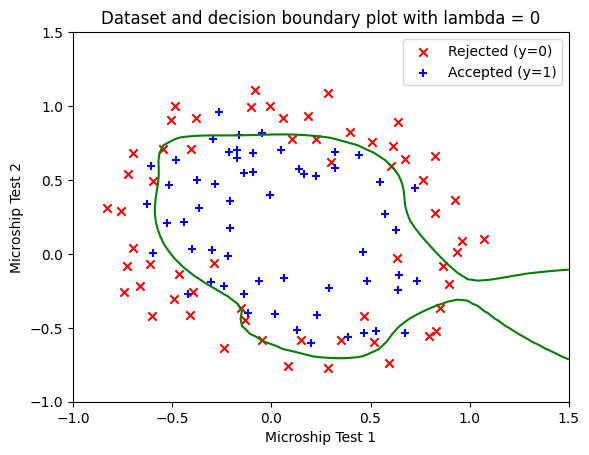

In [5]:
def trainAndPlotDecisionBoundary(X_original, X_poly, y, theta_init, lmd):
    # Training
    theta = trainLogisticReg(X_poly, y, theta_init, lmd)
    
    fig, ax = plt.subplots()
    ax.set_xlabel("Microship Test 1")
    ax.set_ylabel("Microship Test 2")
    
    # Plotting the original dataset
    X0 = X_original[y==0]
    X1 = X_original[y==1]
    ax.scatter(X0[:, 0], X0[:, 1], color="red", marker="x", label="Rejected (y=0)")
    ax.scatter(X1[:, 0], X1[:, 1], color="blue", marker="+", label="Accepted (y=1)")
    
    # Plotting the nonlinear decision boundary
    x1_plot = np.linspace(-1, 1.5, 50)
    x2_plot = np.linspace(-1, 1.5, 50)
    X1_plot, X2_plot = np.meshgrid(x1_plot, x2_plot)
    
    z = np.zeros((len(x1_plot), len(x2_plot)))
    for i in range(len(x1_plot)):
        for j in range(len(x2_plot)):
            z[i][j] = mapFeature(x1_plot[i:i+1], x2_plot[j:j+1]) @ theta
            
    ax.contour(X1_plot, X2_plot, z, [0], colors="green")
    
    ax.set_title("Dataset and decision boundary plot with lambda = {}".format(lmd))
    ax.legend()
    plt.show()


# Here we call the function using the an initial theta of zeros, and lmd = 0 (no regularization):
trainAndPlotDecisionBoundary(X, X_poly, y, theta_init, lmd=0)

## Regularization Strength Comparison

Different values of the regularization parameter are tested to observe how model flexibility changes. Lower regularization can lead to complex boundaries, while stronger regularization produces smoother decision regions.

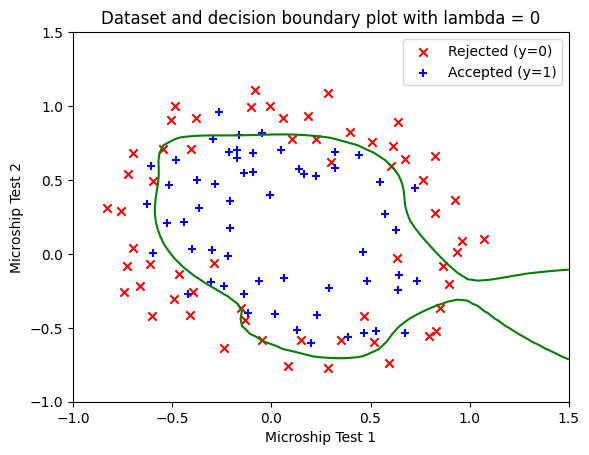

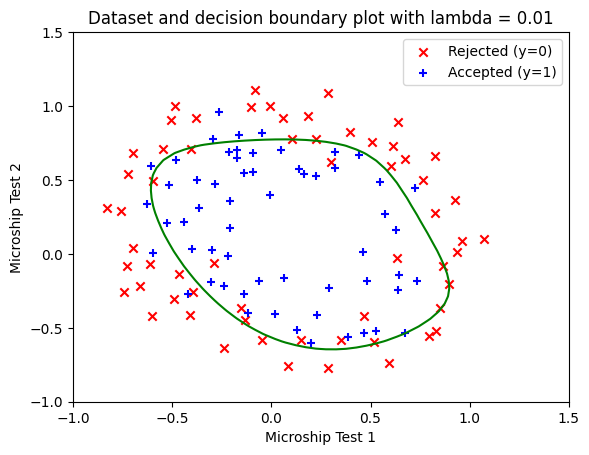

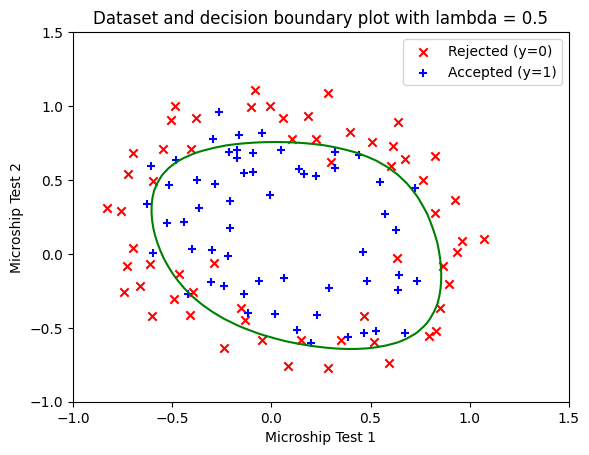

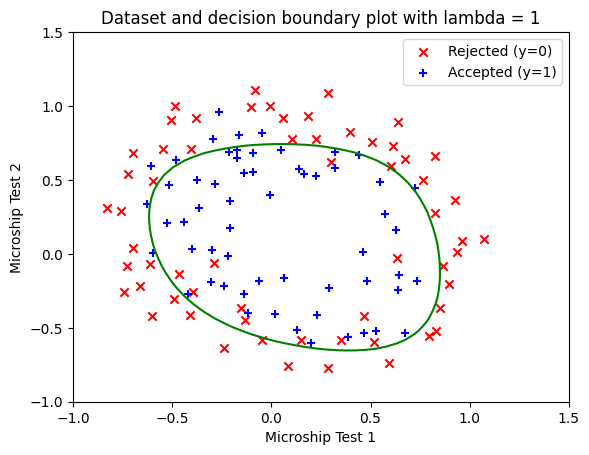

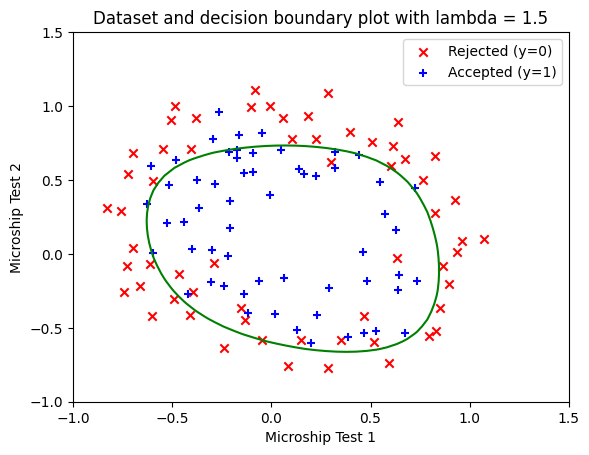

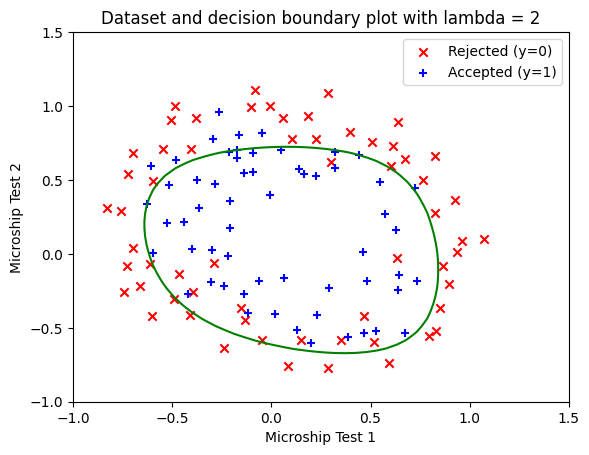

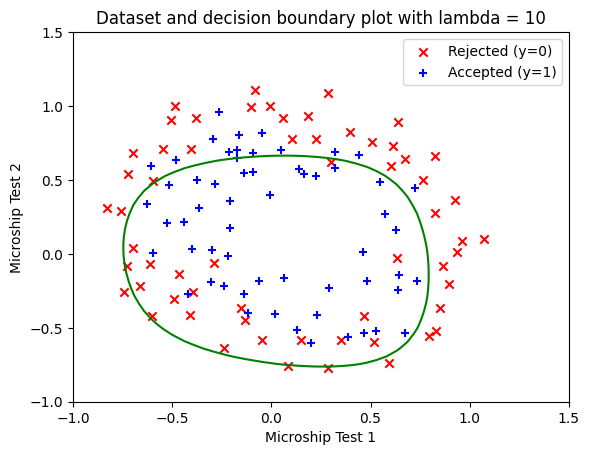

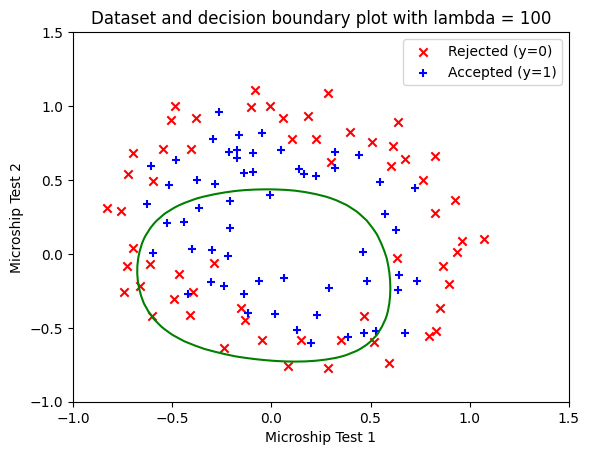

In [ ]:
""" 
Calling the function trainAndPlotDecisionBoundary(..) with various values of lmd
"""
lambda_ = [0,0.01,0.5,1,1.5,2,10,100]

for lmd in lambda_:
    trainAndPlotDecisionBoundary(X, X_poly, y, theta_init, lmd)
    

## Experiment Summary

This experiment demonstrates how regularized logistic regression can be used for nonlinear binary classification after polynomial feature mapping. The decision-boundary plots show how different regularization values affect model flexibility and generalization.

From a portfolio perspective, this notebook shows practical understanding of classification, regularized optimization, nonlinear feature mapping, and visual model evaluation.